<a href="https://colab.research.google.com/github/NidhiThakare/AML_Practicals/blob/main/Experiment_2_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving gender_submission.csv to gender_submission.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import (
    SelectKBest,
    chi2,
    f_classif,
    mutual_info_classif,
    VarianceThreshold
)

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:
df = pd.read_csv(list(uploaded.keys())[0])

print("Dataset Loaded Successfully!")
print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Shape:", df.shape)


Dataset Loaded Successfully!

First 5 Rows:


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1



Dataset Shape: (418, 2)


In [ ]:

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB

Missing Values:
PassengerId    0
Survived       0
dtype: int64


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numerical missing values with mean
if len(num_cols) > 0:
    num_imputer = SimpleImputer(strategy='mean')
    df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Fill categorical missing values with most frequent value
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("\nMissing values handled successfully!")



Missing values handled successfully!


In [ ]:
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("\nCategorical columns encoded successfully!")


Categorical columns encoded successfully!


In [ ]:

print("\nColumns in dataset:")
print(df.columns)


target_column = df.columns[-1]

X = df.drop(target_column, axis=1)
y = df[target_column]

print("\nTarget Variable:", target_column)
print("Feature Matrix Shape:", X.shape)


Columns in dataset:
Index(['PassengerId', 'Survived'], dtype='object')

Target Variable: Survived
Feature Matrix Shape: (418, 1)


In [ ]:
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

print("\nFeature scaling completed!")


Feature scaling completed!


In [ ]:
correlations = []

for col in X.columns:
    corr = np.corrcoef(X[col], y)[0, 1]
    correlations.append(abs(corr))

pearson_scores = pd.DataFrame({
    'Feature': X.columns,
    'Correlation Score': correlations
})

pearson_scores = pearson_scores.sort_values(
    by='Correlation Score',
    ascending=False
)

print("\nTop Features by Pearson Correlation:")
display(pearson_scores.head(10))


Top Features by Pearson Correlation:


,Feature,Correlation Score
0,PassengerId,0.023245


In [ ]:


chi_selector = SelectKBest(score_func=chi2, k='all')
chi_selector.fit(X_scaled, y)

chi_scores = pd.DataFrame({
    'Feature': X.columns,
    'Chi2 Score': chi_selector.scores_
})

chi_scores = chi_scores.sort_values(
    by='Chi2 Score',
    ascending=False
)

print("\nTop Features by Chi-Square:")
display(chi_scores.head(10))




Top Features by Chi-Square:


,Feature,Chi2 Score
0,PassengerId,0.037824


In [ ]:
mi_scores = mutual_info_classif(X, y)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual Info Score': mi_scores
})

mi_df = mi_df.sort_values(
    by='Mutual Info Score',
    ascending=False
)

print("\nTop Features by Mutual Information:")
display(mi_df.head(10))


Top Features by Mutual Information:


,Feature,Mutual Info Score
0,PassengerId,0


In [ ]:
var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(X)

variance_scores = pd.DataFrame({
    'Feature': X.columns,
    'Variance Score': X.var().values
})

variance_scores = variance_scores.sort_values(
    by='Variance Score',
    ascending=False
)

print("\nTop Features by Variance Threshold:")
display(variance_scores.head(10))



Top Features by Variance Threshold:


,Feature,Variance Score
0,PassengerId,14595.166667


In [ ]:
f_selector = SelectKBest(score_func=f_classif, k='all')
f_selector.fit(X_scaled, y)

anova_scores = pd.DataFrame({
    'Feature': X.columns,
    'ANOVA Score': f_selector.scores_
})

anova_scores = anova_scores.sort_values(
    by='ANOVA Score',
    ascending=False
)

print("\nTop Features by ANOVA (F-value):")
display(anova_scores.head(10))

comparison = pd.DataFrame({
    'Pearson': pearson_scores['Feature'].head(5).values,
    'Chi-Square': chi_scores['Feature'].head(5).values,
    'ANOVA': anova_scores['Feature'].head(5).values,
    'Mutual Info': mi_df['Feature'].head(5).values,
    'Variance Threshold': variance_scores['Feature'].head(5).values
})

display(comparison)


Top Features by ANOVA (F-value):


,Feature,ANOVA Score
0,PassengerId,0.224901


,Pearson,Chi-Square,ANOVA,Mutual Info,Variance Threshold
0,PassengerId,PassengerId,PassengerId,PassengerId,PassengerId


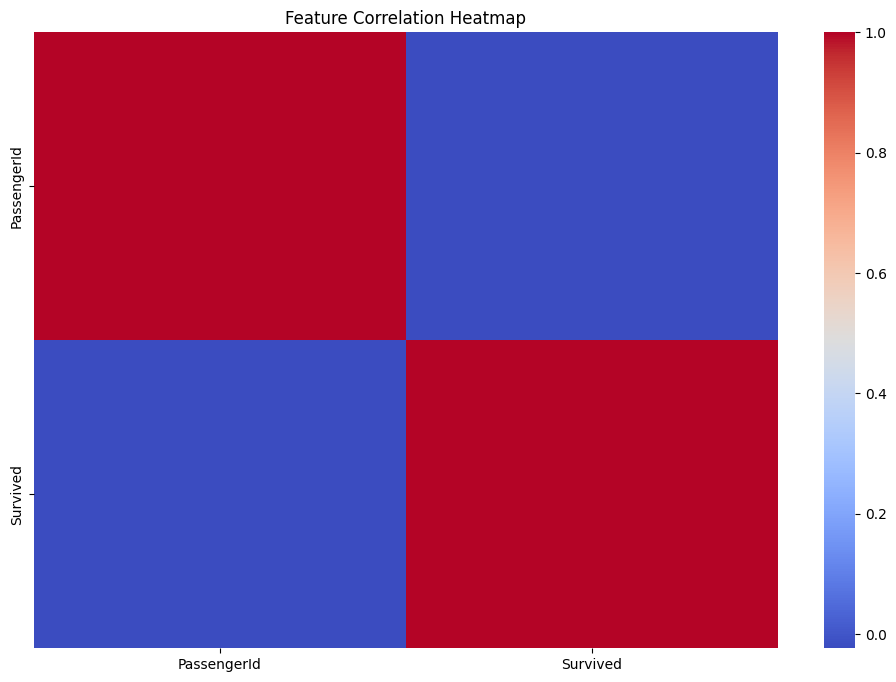

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:
print("\nExperiment Completed Successfully!")
print("""
Applied 5 Filter Methods:
1. Pearson Correlation
2. Chi-Square Test
3. ANOVA F-Test
4. Mutual Information
5. Variance Threshold

Top features for each method displayed successfully.
""")


Experiment Completed Successfully!

Applied 5 Filter Methods:
1. Pearson Correlation
2. Chi-Square Test
3. ANOVA F-Test
4. Mutual Information
5. Variance Threshold

Top features for each method displayed successfully.

